In [32]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt



In [33]:
class CoachVocalDataset(Dataset):
def __init__(self, directorio_base, duracion_segundos=2, sample_rate=16000):
self.directorio = directorio_base
self.sr_objetivo = sample_rate
self.muestras_objetivo = sample_rate * duracion_segundos


self.clases = {"breathy": 0, "belt": 1, "straight": 2}
self.archivos = []
self.etiquetas = []


for nombre_clase, id_clase in self.clases.items():
ruta_clase = os.path.join(directorio_base, nombre_clase)
if os.path.exists(ruta_clase):
for archivo in os.listdir(ruta_clase):
if archivo.endswith('.wav'):
self.archivos.append(os.path.join(ruta_clase, archivo))
self.etiquetas.append(id_clase)

print(f"Dataset inicializado. Total de audios encontrados: {len(self.archivos)}")

def __len__(self):
return len(self.archivos)

def __getitem__(self, idx):
ruta_audio = self.archivos[idx]
etiqueta = self.etiquetas[idx]


import soundfile as sf
data, sr = sf.read(ruta_audio)


waveform = torch.FloatTensor(data)
if len(waveform.shape) == 1:
waveform = waveform.unsqueeze(0)
else:
waveform = waveform.t()


if waveform.shape[0] > 1:
waveform = torch.mean(waveform, dim=0, keepdim=True)


if sr != self.sr_objetivo:
resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sr_objetivo)
waveform = resampler(waveform)


if waveform.shape[1] > self.muestras_objetivo:
waveform = waveform[:, :self.muestras_objetivo]
elif waveform.shape[1] < self.muestras_objetivo:
pad_amount = self.muestras_objetivo - waveform.shape[1]
waveform = torch.nn.functional.pad(waveform, (0, pad_amount))


transformador = torchaudio.transforms.Spectrogram(n_fft=400, hop_length=160)
espectrograma = transformador(waveform)


espectrograma = torch.log2(espectrograma + 1e-6)

return espectrograma, torch.tensor(etiqueta, dtype=torch.long)


Dataset inicializado. Total de audios encontrados: 299

 Tamaño del Lote de Espectrogramas: torch.Size([8, 1, 201, 201])
 Etiquetas del Lote: tensor([1, 2, 2, 1, 1, 1, 2, 2])


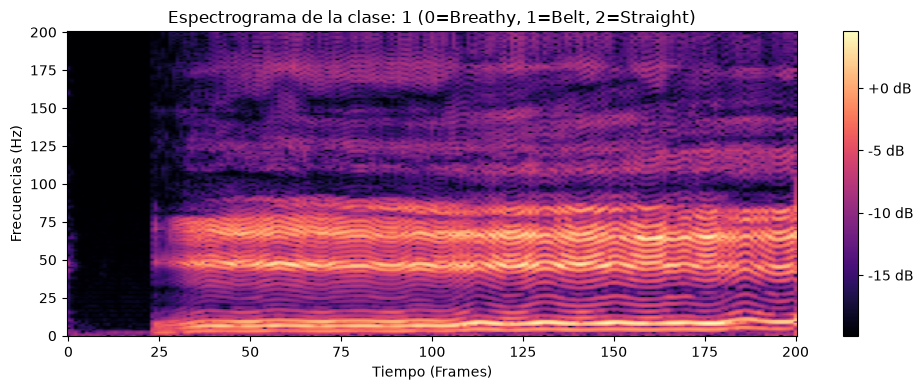

In [34]:

dataset = CoachVocalDataset(directorio_base="datos")


dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

try:
espectrogramas, etiquetas = next(iter(dataloader))
print(f"\n Tamaño del Lote de Espectrogramas: {espectrogramas.shape}")
print(f" Etiquetas del Lote: {etiquetas}")

plt.figure(figsize=(10, 4))
plt.imshow(espectrogramas[0][0].numpy(), cmap='magma', aspect='auto', origin='lower')
plt.title(f"Espectrograma de la clase: {etiquetas[0].item()} (0=Breathy, 1=Belt, 2=Straight)")
plt.ylabel("Frecuencias (Hz)")
plt.xlabel("Tiempo (Frames)")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()
except Exception as e:
print(f"\n Ocurrió un error: {e}")
